In [8]:
import pandas as pd

matches = pd.read_csv("/Users/anantmohansrivastav/Desktop/AI-Cricket-Intelligence/data/matches.csv")

deliveries = pd.read_csv("/Users/anantmohansrivastav/Desktop/AI-Cricket-Intelligence/data/deliveries.csv")

print(matches.head())
print(deliveries.head())

       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0        Kolkat

In [9]:
print(matches.columns)
print(deliveries.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='str')
Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')


In [10]:
print(matches.shape)
print(deliveries.shape)

(1095, 20)
(260920, 17)


In [11]:
matches.info() 
matches.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [14]:
top_batsmen = deliveries.groupby("batter")["batsman_runs"].sum()

top_batsmen = top_batsmen.sort_values(ascending=False)

print(top_batsmen.head(10))

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


In [15]:
print(matches["season"].unique())

<StringArray>
['2007/08',    '2009', '2009/10',    '2011',    '2012',    '2013',    '2014',
    '2015',    '2016',    '2017',    '2018',    '2019', '2020/21',    '2021',
    '2022',    '2023',    '2024']
Length: 17, dtype: str


In [18]:
matches_2019 = matches[matches["season"] == "2019"]

print(matches_2019.head())

          id season     city        date match_type  player_of_match  \
696  1175356   2019  Chennai  2019-03-23     League  Harbhajan Singh   
697  1175357   2019  Kolkata  2019-03-24     League       AD Russell   
698  1175358   2019   Mumbai  2019-03-24     League          RR Pant   
699  1175359   2019   Jaipur  2019-03-25     League         CH Gayle   
700  1175360   2019    Delhi  2019-03-26     League        SR Watson   

                      venue                        team1  \
696  MA Chidambaram Stadium  Royal Challengers Bangalore   
697            Eden Gardens          Sunrisers Hyderabad   
698        Wankhede Stadium               Delhi Capitals   
699  Sawai Mansingh Stadium              Kings XI Punjab   
700    Arun Jaitley Stadium               Delhi Capitals   

                     team2            toss_winner toss_decision  \
696    Chennai Super Kings    Chennai Super Kings         field   
697  Kolkata Knight Riders  Kolkata Knight Riders         field   
698  

In [17]:
print(matches["season"].unique())

<StringArray>
['2007/08',    '2009', '2009/10',    '2011',    '2012',    '2013',    '2014',
    '2015',    '2016',    '2017',    '2018',    '2019', '2020/21',    '2021',
    '2022',    '2023',    '2024']
Length: 17, dtype: str


In [19]:
merged_data = deliveries.merge(
    matches[["id", "season"]],
    left_on="match_id",
    right_on="id"
)
season_runs = merged_data.groupby(
    ["season", "batter"]
)["batsman_runs"].sum()
season_runs = season_runs.reset_index()
top_scorers = season_runs.loc[
    season_runs.groupby("season")["batsman_runs"].idxmax()
]
print(top_scorers)

       season         batter  batsman_runs
115   2007/08       SE Marsh           616
229      2009      ML Hayden           572
446   2009/10   SR Tendulkar           618
502      2011       CH Gayle           608
684      2012       CH Gayle           733
910      2013     MEK Hussey           733
1088     2014     RV Uthappa           660
1148     2015      DA Warner           562
1383     2016        V Kohli           973
1422     2017      DA Warner           641
1594     2018  KS Williamson           735
1694     2019      DA Warner           692
1866  2020/21       KL Rahul           676
2051     2021     RD Gaikwad           635
2144     2022     JC Buttler           863
2423     2023   Shubman Gill           890
2606     2024        V Kohli           741


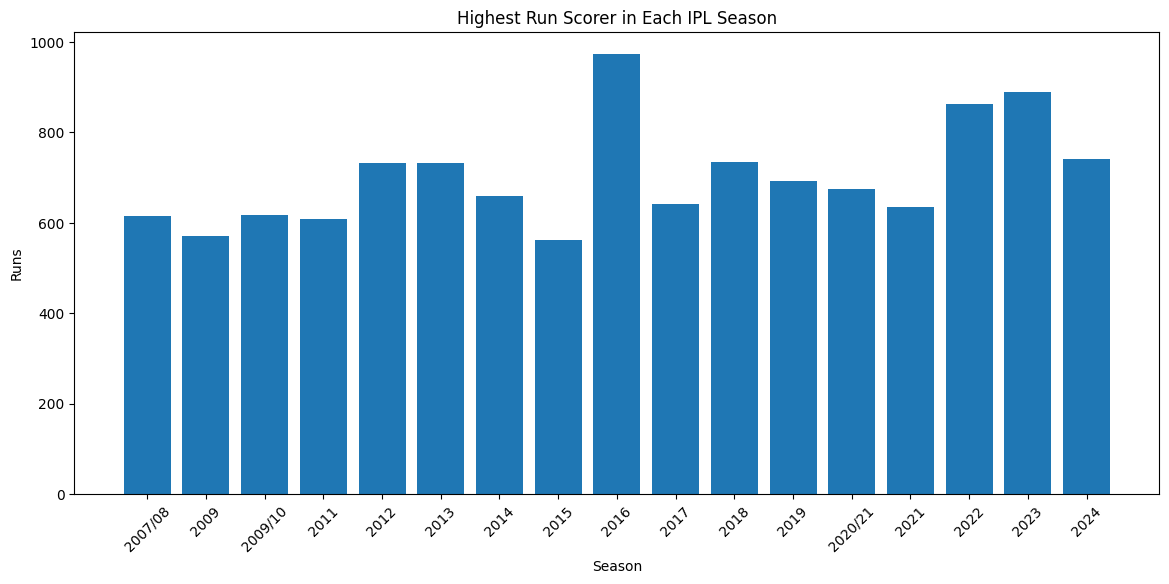

       season         batter  batsman_runs
115   2007/08       SE Marsh           616
229      2009      ML Hayden           572
446   2009/10   SR Tendulkar           618
502      2011       CH Gayle           608
684      2012       CH Gayle           733
910      2013     MEK Hussey           733
1088     2014     RV Uthappa           660
1148     2015      DA Warner           562
1383     2016        V Kohli           973
1422     2017      DA Warner           641
1594     2018  KS Williamson           735
1694     2019      DA Warner           692
1866  2020/21       KL Rahul           676
2051     2021     RD Gaikwad           635
2144     2022     JC Buttler           863
2423     2023   Shubman Gill           890
2606     2024        V Kohli           741


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
matches = pd.read_csv("/Users/anantmohansrivastav/Desktop/AI-Cricket-Intelligence/data/matches.csv")
deliveries = pd.read_csv("/Users/anantmohansrivastav/Desktop/AI-Cricket-Intelligence/data/deliveries.csv")

# Merge deliveries with season
merged_data = deliveries.merge(
    matches[["id", "season"]],
    left_on="match_id",
    right_on="id"
)

# Runs by batter in each season
season_runs = merged_data.groupby(
    ["season", "batter"]
)["batsman_runs"].sum().reset_index()

# Highest scorer each season
top_scorers = season_runs.loc[
    season_runs.groupby("season")["batsman_runs"].idxmax()
]

# Plot
plt.figure(figsize=(14,6))
plt.bar(
    top_scorers["season"].astype(str),
    top_scorers["batsman_runs"]
)

plt.xticks(rotation=45)
plt.xlabel("Season")
plt.ylabel("Runs")
plt.title("Highest Run Scorer in Each IPL Season")
plt.show()

# Also print table
print(top_scorers)

In [4]:
print(deliveries.columns.tolist())

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


position
1    9
2    4
3    4
Name: count, dtype: int64


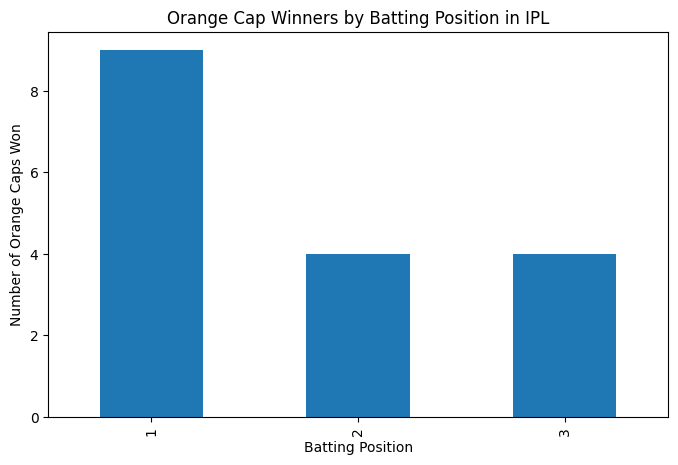

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
matches = pd.read_csv("/Users/anantmohansrivastav/Desktop/AI-Cricket-Intelligence/data/matches.csv")
deliveries = pd.read_csv("/Users/anantmohansrivastav/Desktop/AI-Cricket-Intelligence/data/deliveries.csv")

# Merge season into deliveries
merged = deliveries.merge(
    matches[["id", "season"]],
    left_on="match_id",
    right_on="id"
)

# -------- ORANGE CAP WINNER EACH SEASON --------
season_runs = merged.groupby(
    ["season", "batter"]
)["batsman_runs"].sum().reset_index()

orange_cap_winners = season_runs.loc[
    season_runs.groupby("season")["batsman_runs"].idxmax()
]

# -------- FIND BATTING POSITION --------
batting_order = (
    merged.groupby(["match_id", "inning"])["batter"]
    .apply(lambda x: pd.Series(pd.unique(x)).reset_index(drop=True))
    .reset_index()
)

batting_order.columns = ["match_id", "inning", "position", "batter"]
batting_order["position"] += 1

# Merge batting positions
player_positions = merged.merge(
    batting_order,
    on=["match_id", "inning", "batter"]
)

# Most common batting position of each batter
most_common_position = (
    player_positions.groupby(["batter", "position"])
    .size()
    .reset_index(name="count")
)

most_common_position = most_common_position.loc[
    most_common_position.groupby("batter")["count"].idxmax()
]

# Merge with orange cap winners
orange_cap_positions = orange_cap_winners.merge(
    most_common_position[["batter", "position"]],
    on="batter"
)

# Count wins by batting position
position_counts = orange_cap_positions["position"].value_counts().sort_index()

print(position_counts)

# Plot
plt.figure(figsize=(8,5))
position_counts.plot(kind="bar")

plt.xlabel("Batting Position")
plt.ylabel("Number of Orange Caps Won")
plt.title("Orange Cap Winners by Batting Position in IPL")

plt.show()

In [6]:
kohli = merged_data[merged_data["batter"] == "V Kohli"]

kohli_runs_by_season = kohli.groupby("season")["batsman_runs"].sum()

print(kohli_runs_by_season)

season
2007/08    165
2009       246
2009/10    307
2011       557
2012       364
2013       639
2014       359
2015       505
2016       973
2017       308
2018       530
2019       464
2020/21    471
2021       405
2022       341
2023       639
2024       741
Name: batsman_runs, dtype: int64


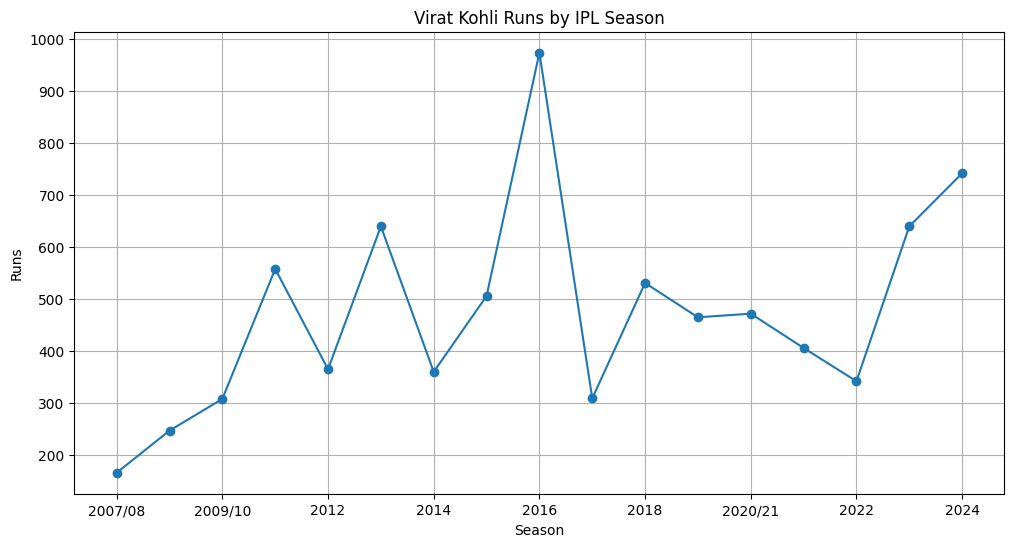

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

kohli_runs_by_season.plot(marker="o")

plt.title("Virat Kohli Runs by IPL Season")
plt.xlabel("Season")
plt.ylabel("Runs")

plt.grid(True)
plt.show()


In [8]:
import pandas as pd

# Batter insights table
batter_insights = deliveries.groupby("batter").agg(
    innings=("match_id", "nunique"),
    total_runs=("batsman_runs", "sum"),
    balls_faced=("ball", "count")
).reset_index()

# Strike rate
batter_insights["strike_rate"] = (
    batter_insights["total_runs"] / batter_insights["balls_faced"]
) * 100

# Boundaries
fours = deliveries[deliveries["batsman_runs"] == 4].groupby("batter").size()
sixes = deliveries[deliveries["batsman_runs"] == 6].groupby("batter").size()

# Merge
batter_insights["fours"] = batter_insights["batter"].map(fours).fillna(0)
batter_insights["sixes"] = batter_insights["batter"].map(sixes).fillna(0)

# Sort by total runs
batter_insights = batter_insights.sort_values(
    by="total_runs",
    ascending=False
)

print(batter_insights.head(20))

             batter  innings  total_runs  balls_faced  strike_rate  fours  \
631         V Kohli      244        8014         6236   128.511867  708.0   
512        S Dhawan      221        6769         5483   123.454313  768.0   
477       RG Sharma      251        6630         5183   127.918194  599.0   
147       DA Warner      184        6567         4849   135.429986  663.0   
546        SK Raina      200        5536         4177   132.535312  506.0   
374        MS Dhoni      228        5243         3947   132.835065  363.0   
30   AB de Villiers      170        5181         3487   148.580442  414.0   
124        CH Gayle      141        4997         3516   142.121729  408.0   
501      RV Uthappa      197        4954         3927   126.152279  481.0   
282      KD Karthik      233        4843         3687   131.353404  466.0   
289        KL Rahul      122        4689         3578   131.050866  400.0   
50        AM Rahane      171        4642         3858   120.321410  479.0   

In [9]:
import pandas as pd

# Total runs by batter
runs = deliveries.groupby("batter")["batsman_runs"].sum()

# Balls faced
balls = deliveries.groupby("batter").size()

# Innings played (unique matches)
innings = deliveries.groupby("batter")["match_id"].nunique()

# Number of 4s
fours = deliveries[deliveries["batsman_runs"] == 4].groupby("batter").size()

# Number of 6s
sixes = deliveries[deliveries["batsman_runs"] == 6].groupby("batter").size()

# Highest score in a single match
highest_score = (
    deliveries.groupby(["batter", "match_id"])["batsman_runs"]
    .sum()
    .groupby("batter")
    .max()
)

# Combine everything
batter_insights = pd.DataFrame({
    "innings": innings,
    "runs": runs,
    "balls_faced": balls,
    "highest_score": highest_score,
    "fours": fours,
    "sixes": sixes
}).fillna(0)

# Strike rate
batter_insights["strike_rate"] = (
    batter_insights["runs"] / batter_insights["balls_faced"]
) * 100

# Sort by runs descending
batter_insights = batter_insights.sort_values(
    by="runs",
    ascending=False
)

# Show top 20
print(batter_insights.head(20))

                innings  runs  balls_faced  highest_score  fours  sixes  \
batter                                                                    
V Kohli             244  8014         6236            113  708.0  273.0   
S Dhawan            221  6769         5483            106  768.0  153.0   
RG Sharma           251  6630         5183            109  599.0  281.0   
DA Warner           184  6567         4849            126  663.0  236.0   
SK Raina            200  5536         4177            100  506.0  204.0   
MS Dhoni            228  5243         3947             84  363.0  252.0   
AB de Villiers      170  5181         3487            133  414.0  253.0   
CH Gayle            141  4997         3516            175  408.0  359.0   
RV Uthappa          197  4954         3927             88  481.0  182.0   
KD Karthik          233  4843         3687             97  466.0  161.0   
KL Rahul            122  4689         3578            132  400.0  187.0   
AM Rahane           171  

In [14]:
# All wicket deliveries

wicket_balls = deliveries[
    deliveries["player_dismissed"].notna()
]

# Count wickets bowler-wise

bowler_wickets = (
    wicket_balls
    .groupby("bowler")
    .size()
)

print(bowler_wickets.sort_values(ascending=False).head(50))

bowler
YS Chahal          213
DJ Bravo           207
PP Chawla          201
SP Narine          200
R Ashwin           198
B Kumar            195
SL Malinga         188
A Mishra           183
JJ Bumrah          182
RA Jadeja          169
UT Yadav           163
Harbhajan Singh    161
Rashid Khan        157
Sandeep Sharma     153
HV Patel           151
MM Sharma          147
Mohammed Shami     144
AR Patel           131
TA Boult           128
R Vinay Kumar      127
K Rabada           126
AD Russell         125
A Nehra            121
Z Khan             119
JD Unadkat         109
SR Watson          107
CH Morris          107
DW Steyn           105
P Kumar            102
SN Thakur          100
RP Singh           100
PP Ojha             99
IK Pathan           99
I Sharma            96
JA Morkel           96
Mohammed Siraj      96
DS Kulkarni         91
Kuldeep Yadav       90
M Morkel            88
Imran Tahir         86
CV Varun            85
L Balaji            85
Arshdeep Singh      84
R Bh

In [15]:
runs_conceded = (
    deliveries
    .groupby("bowler")["total_runs"]
    .sum()
)

print(runs_conceded.head())

bowler
A Ashish Reddy    400
A Badoni           37
A Chandila        245
A Choudhary       144
A Dananjaya        47
Name: total_runs, dtype: int64


In [17]:
balls_bowled = (
    deliveries
    .groupby("bowler")
    .size()
)

print(balls_bowled.head())


bowler
A Ashish Reddy    270
A Badoni           25
A Chandila        234
A Choudhary       108
A Dananjaya        25
dtype: int64


In [19]:
overs_bowled = balls_bowled / 6
print(overs_bowled.head())

bowler
A Ashish Reddy    45.000000
A Badoni           4.166667
A Chandila        39.000000
A Choudhary       18.000000
A Dananjaya        4.166667
dtype: float64


In [21]:
economy = (
    runs_conceded /
    overs_bowled
)
print(economy.head())

bowler
A Ashish Reddy     8.888889
A Badoni           8.880000
A Chandila         6.282051
A Choudhary        8.000000
A Dananjaya       11.280000
dtype: float64


In [23]:
bowler_insights = bowler_insights.sort_values(
    by="wickets",
    ascending=False
)

print(bowler_insights.head(20))

                 wickets  runs_conceded  balls_bowled   economy
bowler                                                         
YS Chahal          213.0           4681          3628  7.741455
DJ Bravo           207.0           4436          3296  8.075243
PP Chawla          201.0           5179          3895  7.977920
SP Narine          200.0           4672          4146  6.761216
R Ashwin           198.0           5435          4679  6.969438
B Kumar            195.0           5051          4060  7.464532
SL Malinga         188.0           3486          2974  7.032952
A Mishra           183.0           4193          3444  7.304878
JJ Bumrah          182.0           3840          3185  7.233909
RA Jadeja          169.0           4917          3895  7.574326
UT Yadav           163.0           4442          3190  8.354859
Harbhajan Singh    161.0           4101          3496  7.038330
Rashid Khan        157.0           3340          2901  6.907963
Sandeep Sharma     153.0           3758 

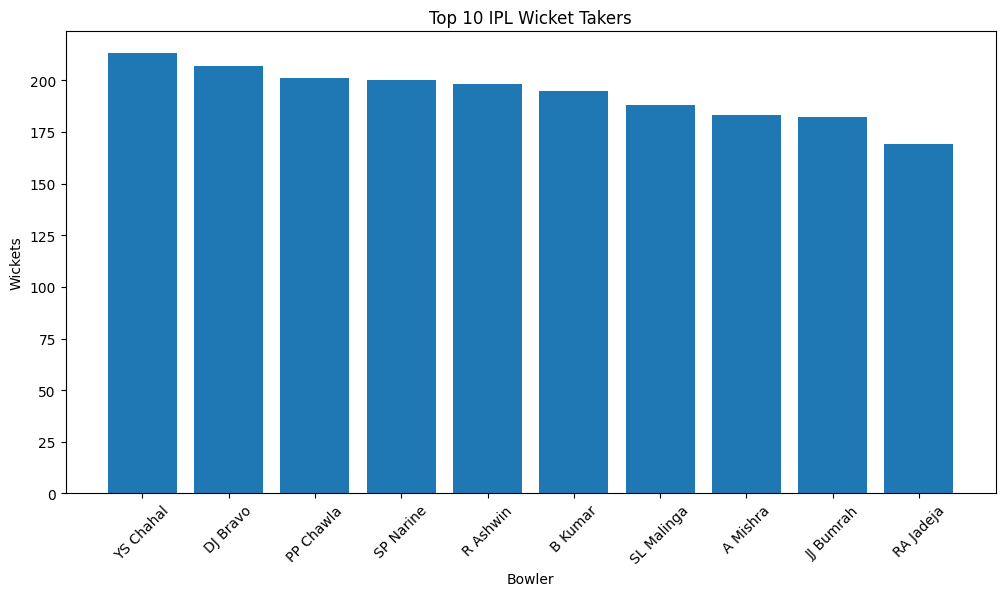

In [24]:
import matplotlib.pyplot as plt

top10 = bowler_insights.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10.index,
    top10["wickets"]
)

plt.xticks(rotation=45)

plt.title("Top 10 IPL Wicket Takers")

plt.xlabel("Bowler")

plt.ylabel("Wickets")

plt.show()

In [26]:
print(batter_insights.head(20))

                innings  runs  balls_faced  highest_score  fours  sixes  \
batter                                                                    
V Kohli             244  8014         6236            113  708.0  273.0   
S Dhawan            221  6769         5483            106  768.0  153.0   
RG Sharma           251  6630         5183            109  599.0  281.0   
DA Warner           184  6567         4849            126  663.0  236.0   
SK Raina            200  5536         4177            100  506.0  204.0   
MS Dhoni            228  5243         3947             84  363.0  252.0   
AB de Villiers      170  5181         3487            133  414.0  253.0   
CH Gayle            141  4997         3516            175  408.0  359.0   
RV Uthappa          197  4954         3927             88  481.0  182.0   
KD Karthik          233  4843         3687             97  466.0  161.0   
KL Rahul            122  4689         3578            132  400.0  187.0   
AM Rahane           171  

In [27]:
# ==========================
# BOWLER ANALYTICS
# ==========================

# wickets

wicket_balls = deliveries[
    deliveries["player_dismissed"].notna()
]

bowler_wickets = (
    wicket_balls
    .groupby("bowler")
    .size()
)

# runs conceded

runs_conceded = (
    deliveries
    .groupby("bowler")["total_runs"]
    .sum()
)

# balls bowled

balls_bowled = (
    deliveries
    .groupby("bowler")
    .size()
)

# economy

economy = (
    runs_conceded /
    (balls_bowled / 6)
)

# final table

bowler_insights = pd.DataFrame({
    "wickets": bowler_wickets,
    "runs_conceded": runs_conceded,
    "balls_bowled": balls_bowled,
    "economy": economy
})

bowler_insights = bowler_insights.fillna(0)

bowler_insights = bowler_insights.sort_values(
    by="wickets",
    ascending=False
)

print(bowler_insights.head(20))

                 wickets  runs_conceded  balls_bowled   economy
bowler                                                         
YS Chahal          213.0           4681          3628  7.741455
DJ Bravo           207.0           4436          3296  8.075243
PP Chawla          201.0           5179          3895  7.977920
SP Narine          200.0           4672          4146  6.761216
R Ashwin           198.0           5435          4679  6.969438
B Kumar            195.0           5051          4060  7.464532
SL Malinga         188.0           3486          2974  7.032952
A Mishra           183.0           4193          3444  7.304878
JJ Bumrah          182.0           3840          3185  7.233909
RA Jadeja          169.0           4917          3895  7.574326
UT Yadav           163.0           4442          3190  8.354859
Harbhajan Singh    161.0           4101          3496  7.038330
Rashid Khan        157.0           3340          2901  6.907963
Sandeep Sharma     153.0           3758 

In [28]:
print(bowler_insights.head(20))

                 wickets  runs_conceded  balls_bowled   economy
bowler                                                         
YS Chahal          213.0           4681          3628  7.741455
DJ Bravo           207.0           4436          3296  8.075243
PP Chawla          201.0           5179          3895  7.977920
SP Narine          200.0           4672          4146  6.761216
R Ashwin           198.0           5435          4679  6.969438
B Kumar            195.0           5051          4060  7.464532
SL Malinga         188.0           3486          2974  7.032952
A Mishra           183.0           4193          3444  7.304878
JJ Bumrah          182.0           3840          3185  7.233909
RA Jadeja          169.0           4917          3895  7.574326
UT Yadav           163.0           4442          3190  8.354859
Harbhajan Singh    161.0           4101          3496  7.038330
Rashid Khan        157.0           3340          2901  6.907963
Sandeep Sharma     153.0           3758 

In [29]:
# ==========================
# TEAM WINS
# ==========================

team_wins = (
    matches["winner"]
    .value_counts()
)

print(team_wins)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


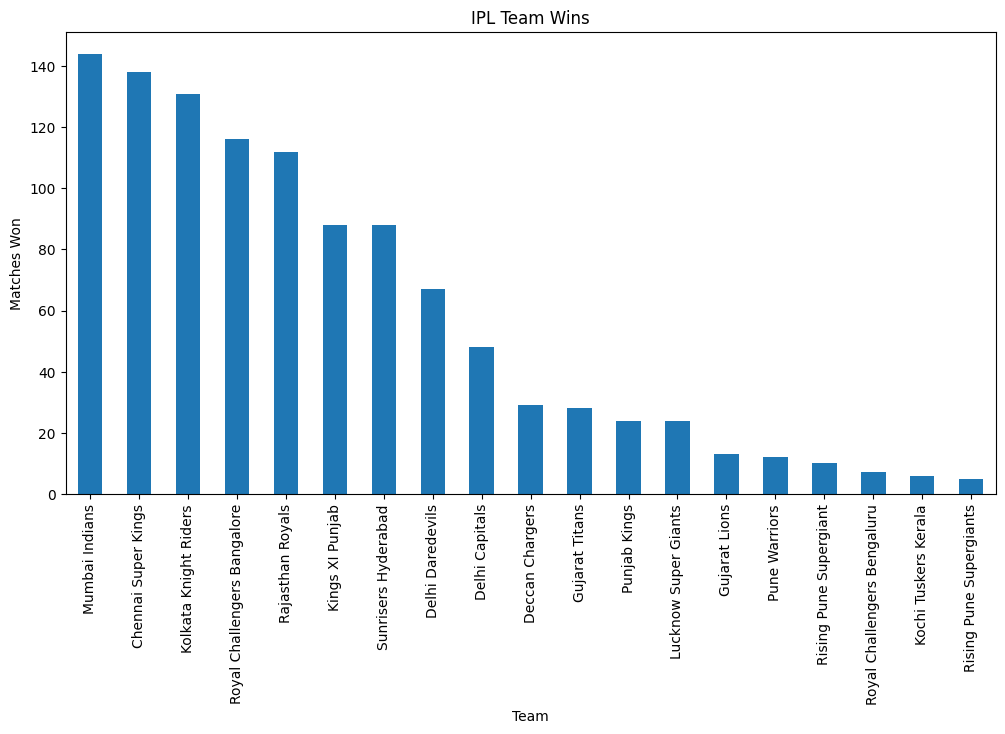

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

team_wins.plot(kind="bar")

plt.title("IPL Team Wins")

plt.xlabel("Team")

plt.ylabel("Matches Won")

plt.show()

In [31]:
# Matches played

team1_matches = matches["team1"].value_counts()

team2_matches = matches["team2"].value_counts()

matches_played = (
    team1_matches
    .add(team2_matches, fill_value=0)
)

# Wins

wins = matches["winner"].value_counts()

# Win percentage

win_percentage = (
    wins / matches_played
) * 100

win_percentage = (
    win_percentage
    .sort_values(ascending=False)
)

print(win_percentage)

winner
Rising Pune Supergiant         62.500000
Gujarat Titans                 62.222222
Chennai Super Kings            57.983193
Mumbai Indians                 55.172414
Lucknow Super Giants           54.545455
Delhi Capitals                 52.747253
Kolkata Knight Riders          52.191235
Rajasthan Royals               50.678733
Sunrisers Hyderabad            48.351648
Royal Challengers Bangalore    48.333333
Royal Challengers Bengaluru    46.666667
Kings XI Punjab                46.315789
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Punjab Kings                   42.857143
Delhi Daredevils               41.614907
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.086957
Name: count, dtype: float64


In [32]:
team_insights = pd.DataFrame({
    "matches_played": matches_played,
    "wins": wins
})

team_insights = team_insights.fillna(0)

team_insights["win_percentage"] = (
    team_insights["wins"] /
    team_insights["matches_played"]
) * 100

team_insights = team_insights.sort_values(
    by="win_percentage",
    ascending=False
)

print(team_insights)

                             matches_played  wins  win_percentage
Rising Pune Supergiant                   16    10       62.500000
Gujarat Titans                           45    28       62.222222
Chennai Super Kings                     238   138       57.983193
Mumbai Indians                          261   144       55.172414
Lucknow Super Giants                     44    24       54.545455
Delhi Capitals                           91    48       52.747253
Kolkata Knight Riders                   251   131       52.191235
Rajasthan Royals                        221   112       50.678733
Sunrisers Hyderabad                     182    88       48.351648
Royal Challengers Bangalore             240   116       48.333333
Royal Challengers Bengaluru              15     7       46.666667
Kings XI Punjab                         190    88       46.315789
Gujarat Lions                            30    13       43.333333
Kochi Tuskers Kerala                     14     6       42.857143
Punjab Kin

In [33]:
toss_win_match_win = matches[
    matches["toss_winner"] ==
    matches["winner"]
]

percentage = (
    len(toss_win_match_win)
    /
    len(matches)
) * 100

print(
    f"Toss winner also won match: {percentage:.2f}%"
)

Toss winner also won match: 50.59%


In [35]:
merged_data = deliveries.merge(
    matches[["id", "venue"]],
    left_on="match_id",
    right_on="id"
)
innings_scores = (
    merged_data
    .groupby(
        ["match_id", "inning", "venue"]
    )["total_runs"]
    .sum()
    .reset_index()
)

print(innings_scores.head())

   match_id  inning                                       venue  total_runs
0    335982       1                       M Chinnaswamy Stadium         222
1    335982       2                       M Chinnaswamy Stadium          82
2    335983       1  Punjab Cricket Association Stadium, Mohali         240
3    335983       2  Punjab Cricket Association Stadium, Mohali         207
4    335984       1                            Feroz Shah Kotla         129


In [36]:
venue_avg_score = (
    innings_scores
    .groupby("venue")["total_runs"]
    .mean()
    .sort_values(ascending=False)
)

print(venue_avg_score.head(20))

venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    200.000000
Arun Jaitley Stadium, Delhi                                           190.343750
Eden Gardens, Kolkata                                                 190.156250
M Chinnaswamy Stadium, Bengaluru                                      190.071429
Himachal Pradesh Cricket Association Stadium, Dharamsala              189.375000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      185.600000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  182.423077
Brabourne Stadium                                                     174.050000
Punjab Cricket Association IS Bindra Stadium                          173.800000
Wankhede Stadium, Mumbai                                              173.188889
Brabourne Stadium, Mumbai                                             171.294118
Sawai Mansingh Stadium, Jaipur                                        171.050000
M.Chinnaswamy Stadium 

In [37]:
top_batting_venues = venue_avg_score.head(10)

print(top_batting_venues)

venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    200.000000
Arun Jaitley Stadium, Delhi                                           190.343750
Eden Gardens, Kolkata                                                 190.156250
M Chinnaswamy Stadium, Bengaluru                                      190.071429
Himachal Pradesh Cricket Association Stadium, Dharamsala              189.375000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      185.600000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  182.423077
Brabourne Stadium                                                     174.050000
Punjab Cricket Association IS Bindra Stadium                          173.800000
Wankhede Stadium, Mumbai                                              173.188889
Name: total_runs, dtype: float64


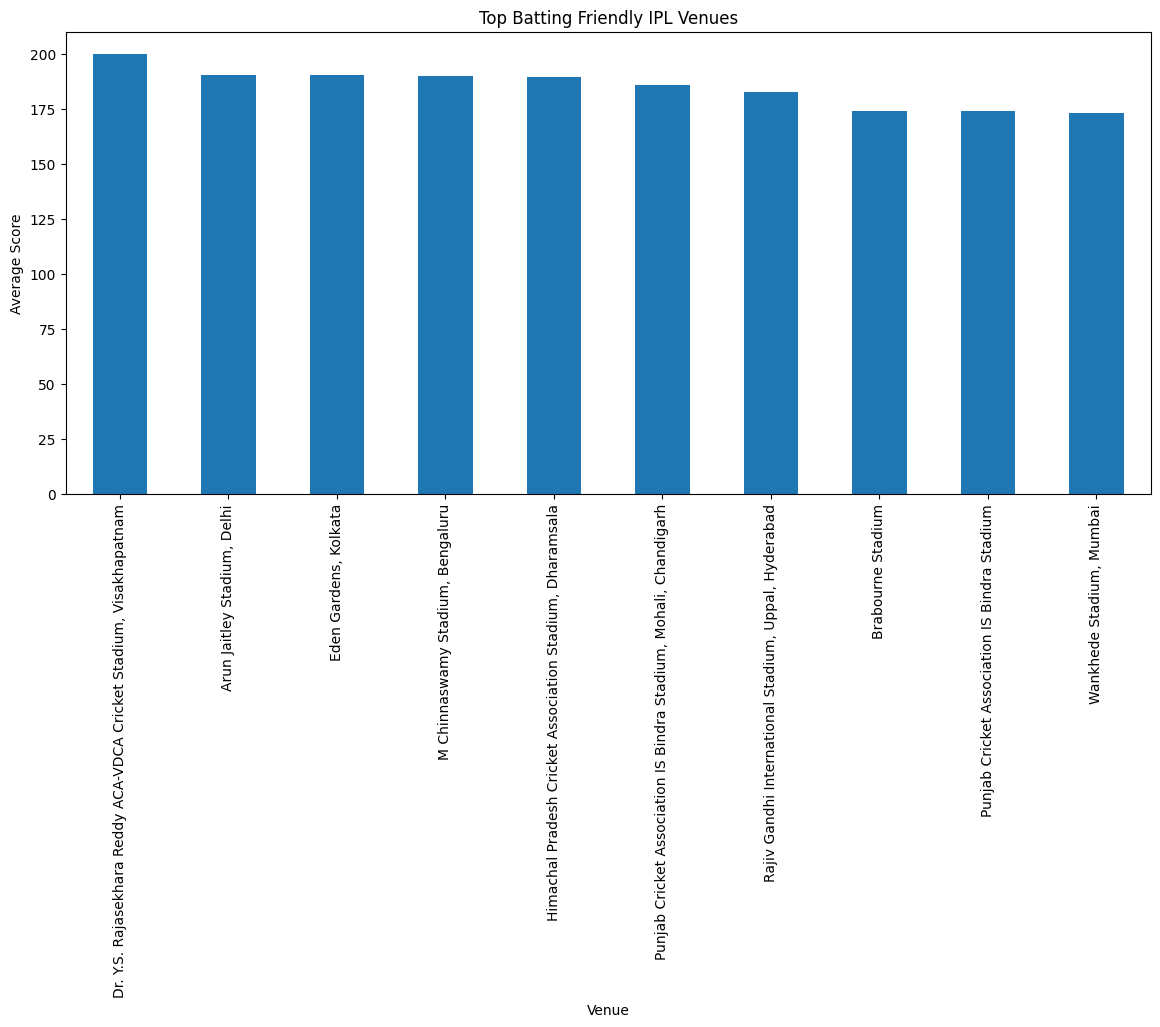

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

top_batting_venues.plot(kind="bar")

plt.title(
    "Top Batting Friendly IPL Venues"
)

plt.xlabel("Venue")

plt.ylabel("Average Score")

plt.show()

In [39]:
highest_score_venue = (
    innings_scores
    .sort_values(
        by="total_runs",
        ascending=False
    )
)

print(
    highest_score_venue[
        ["venue", "total_runs"]
    ].head(10)
)

                                                  venue  total_runs
2133                   M Chinnaswamy Stadium, Bengaluru         287
2089  Rajiv Gandhi International Stadium, Uppal, Hyd...         277
2105  Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...         272
2143                        Arun Jaitley Stadium, Delhi         266
709                               M Chinnaswamy Stadium         263
2158                              Eden Gardens, Kolkata         262
2134                   M Chinnaswamy Stadium, Bengaluru         262
2157                              Eden Gardens, Kolkata         261
2159                        Arun Jaitley Stadium, Delhi         257
2002  Punjab Cricket Association IS Bindra Stadium, ...         257


In [40]:
highest_score_venue = (
    innings_scores
    .sort_values(
        by="total_runs",
        ascending=False
    )
)

print(
    highest_score_venue[
        ["venue", "total_runs"]
    ].head(10)
)

                                                  venue  total_runs
2133                   M Chinnaswamy Stadium, Bengaluru         287
2089  Rajiv Gandhi International Stadium, Uppal, Hyd...         277
2105  Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...         272
2143                        Arun Jaitley Stadium, Delhi         266
709                               M Chinnaswamy Stadium         263
2158                              Eden Gardens, Kolkata         262
2134                   M Chinnaswamy Stadium, Bengaluru         262
2157                              Eden Gardens, Kolkata         261
2159                        Arun Jaitley Stadium, Delhi         257
2002  Punjab Cricket Association IS Bindra Stadium, ...         257


In [41]:
batter_insights.head()

,innings,runs,balls_faced,highest_score,fours,sixes,strike_rate
batter,,,,,,,
V Kohli,244,8014,6236,113,708.0,273.0,128.511867
S Dhawan,221,6769,5483,106,768.0,153.0,123.454313
RG Sharma,251,6630,5183,109,599.0,281.0,127.918194
DA Warner,184,6567,4849,126,663.0,236.0,135.429986
SK Raina,200,5536,4177,100,506.0,204.0,132.535312


In [42]:
batter_insights.to_csv(
    "data/batter_insights.csv"
)

bowler_insights.to_csv(
    "data/bowler_insights.csv"
)

team_insights.to_csv(
    "data/team_insights.csv"
)

In [43]:
ls data

batter_insights.csv  deliveries.csv       team_insights.csv
bowler_insights.csv  matches.csv


In [46]:
batter_insights.to_csv("data/batter_insights.csv")
bowler_insights.to_csv("data/bowler_insights.csv")
team_insights.to_csv("data/team_insights.csv")

In [47]:
ls data


batter_insights.csv  deliveries.csv       team_insights.csv
bowler_insights.csv  matches.csv
